In [1]:
# 04_results_visualization.ipynb
# Purpose: Create final report-ready visualizations from modeling results.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Results Source

The model performance values, Random Forest feature importances, and Lasso coefficients shown below were obtained from `03_modeling.ipynb` using 5-fold GroupKFold cross-validation grouped by water-to-cement ratio decile.

In [2]:
data_file = Path("../data/concrete_featurized.csv")

df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1030, 12)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,w_c_ratio,log_age,w_c_ratio_bin
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111,0.300000,3.332205,0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,0.300000,3.332205,0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535,0.685714,5.598422,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780,0.685714,5.899897,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075,0.966767,5.886104,7


In [3]:
model_results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Random Forest"],
    "Mean MAE": [5.905440, 5.904012, 6.135266],
    "Mean R2": [0.727310, 0.727612, 0.674819]
})

model_results

,Model,Mean MAE,Mean R2
0,Ridge,5.905440,0.727310
1,Lasso,5.904012,0.727612
2,Random Forest,6.135266,0.674819


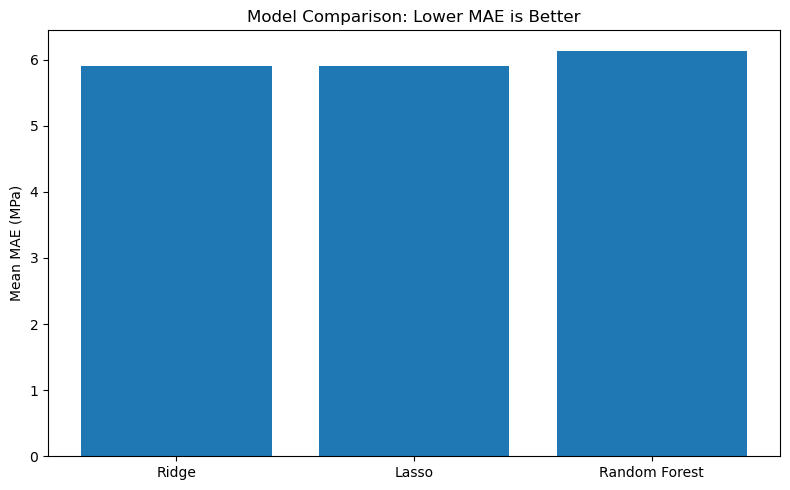

In [4]:
plt.figure(figsize=(8,5))
plt.bar(model_results["Model"], model_results["Mean MAE"])
plt.ylabel("Mean MAE (MPa)")
plt.title("Model Comparison: Lower MAE is Better")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

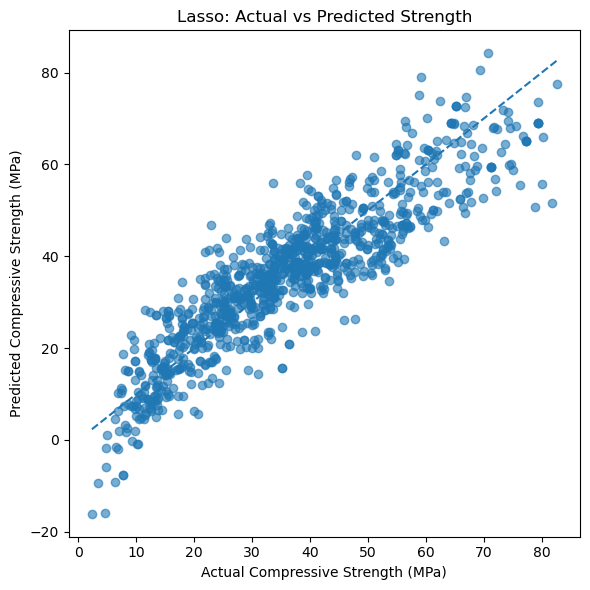

In [7]:
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

feature_cols = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_aggregate", "fine_aggregate", "age", "w_c_ratio", "log_age"
]

X = df[feature_cols]
y = df["compressive_strength"]
groups = df["w_c_ratio_bin"]

cv = GroupKFold(n_splits=5)

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

y_pred = cross_val_predict(
    lasso_model,
    X,
    y,
    cv=cv,
    groups=groups
)

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
plt.xlabel("Actual Compressive Strength (MPa)")
plt.ylabel("Predicted Compressive Strength (MPa)")
plt.title("Lasso: Actual vs Predicted Strength")
plt.tight_layout()
plt.savefig("../figures/lasso_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

### Actual vs Predicted Strength

The parity plot compares measured compressive strength values against Lasso model predictions using GroupKFold cross-validation. Most points follow the dashed diagonal line, showing that the model captures the main strength trends. Some scatter remains, especially at very low and high strengths, which is expected because concrete strength also depends on factors not fully captured in the dataset, such as curing conditions, admixture chemistry, and testing variability.

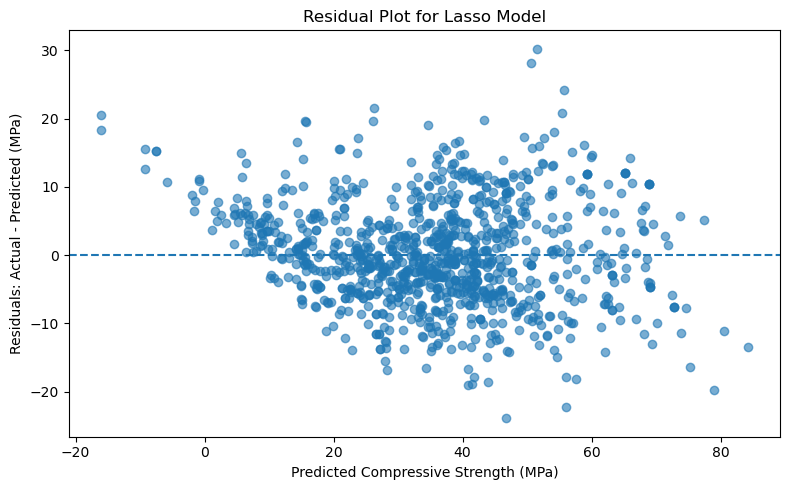

In [8]:
residuals = y - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Compressive Strength (MPa)")
plt.ylabel("Residuals: Actual - Predicted (MPa)")
plt.title("Residual Plot for Lasso Model")
plt.tight_layout()
plt.savefig("../figures/lasso_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Residual Analysis

The residual plot shows that prediction errors are generally centered around zero, indicating that the Lasso model does not exhibit a strong systematic bias. Most residuals fall within approximately ±10 MPa, although a few larger errors are present. The spread of residuals increases somewhat for intermediate and higher predicted strengths, suggesting that prediction uncertainty is larger for some concrete mixtures. Overall, the residual pattern indicates reasonable model performance without severe bias.

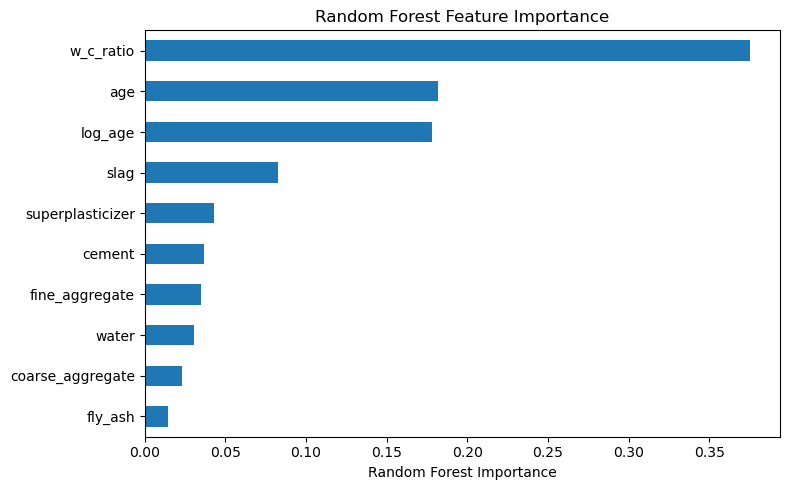

In [5]:
feature_importance = pd.Series({
    "w_c_ratio": 0.375122,
    "age": 0.181771,
    "log_age": 0.177857,
    "slag": 0.082329,
    "superplasticizer": 0.042982,
    "cement": 0.037055,
    "fine_aggregate": 0.034675,
    "water": 0.030759,
    "coarse_aggregate": 0.023276,
    "fly_ash": 0.014175
})

plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind="barh")
plt.xlabel("Random Forest Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

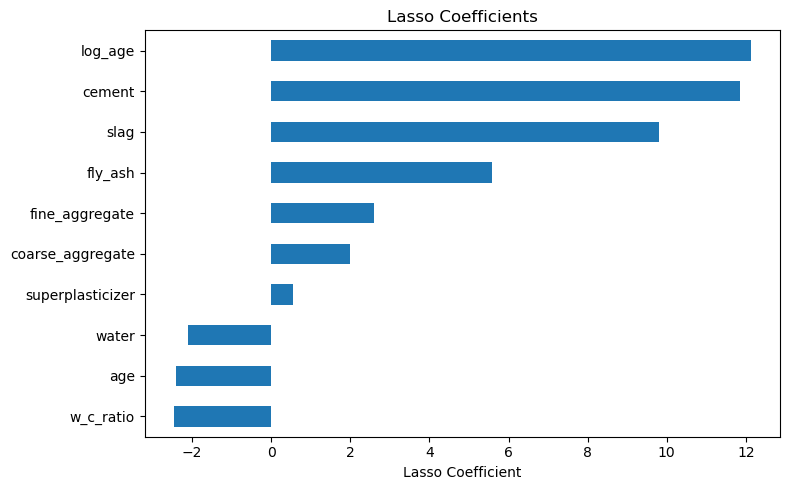

In [6]:
lasso_coefficients = pd.Series({
    "log_age": 12.133152,
    "cement": 11.839796,
    "slag": 9.796828,
    "fly_ash": 5.574294,
    "fine_aggregate": 2.610182,
    "w_c_ratio": -2.467309,
    "age": -2.407992,
    "water": -2.098797,
    "coarse_aggregate": 1.994663,
    "superplasticizer": 0.552624
})

plt.figure(figsize=(8,5))
lasso_coefficients.sort_values().plot(kind="barh")
plt.xlabel("Lasso Coefficient")
plt.title("Lasso Coefficients")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Results Summary

The final model comparison showed that Lasso achieved the lowest mean MAE and highest mean R² under 5-fold GroupKFold cross-validation grouped by water-to-cement ratio decile. Ridge performed nearly identically, while Random Forest performed slightly worse under the grouped validation strategy. This suggests that the engineered physical features, especially water-to-cement ratio and logarithmic curing age, allowed simpler linear models to generalize effectively.

Random Forest feature importance identified water-to-cement ratio, age, and log(age) as the most important predictors. Lasso coefficients also confirmed that log(age), cement, slag, fly ash, and water-to-cement ratio remained meaningful predictors. These results are physically reasonable because compressive strength is strongly controlled by curing time, cementitious binder content, and water-to-cement ratio.